# Congress Trading Signal — notebook de recherche (autonome)

**La question.** Peut-on construire une stratégie systématique qui *copie les transactions déclarées par les
membres du Congrès américain* (STOCK Act) et **bat le marché net de coûts** ? Et la version intégrable
Ramify — substituer chaque action par son **ETF sectoriel** — tient-elle ?

**La réponse, en une ligne.** Le signal d'achat existe mais c'est une **loterie à queue droite** ; la
stratégie *spécifiée par Ramify* dégage un **alpha actions positif mais NON significatif** (V1), **dilué à
≈0/négatif** en ETF (V2) ; **aucune version ne bat SPY en risque-ajusté** → c'est un **produit thématique
livrable** (à la NANC/KRUZ), pas un générateur d'alpha.

**Comment lire.** Ce notebook est **autonome** : aucun fichier `.py` externe. La **Partie 0** définit *tout*
le moteur (chargement, prix, event-study, portefeuille, métriques, sélection) en cellules courtes et
expliquées — on la lit une fois. Les **Parties I-IX** racontent la recherche, du contexte au verdict, en
appelant ces outils. Tout chiffre empirique est calculé dans une cellule ; la littérature est sourcée (URLs).
*(Seules dépendances : `numpy/pandas/scipy/sklearn/matplotlib/yaml`. Données : caches Quiver + prix, lus en
seule lecture.)*

---
# Partie 0 — La boîte à outils (le moteur, en clair)
On définit ici, une fois pour toutes, les fonctions utilisées partout ensuite. Chaque cellule = *à quoi ça
sert → le code*.

**0.1 — Imports & chemins.** Librairies standard + localisation du dossier (et du dépôt, en lecture
seule pour les données).

In [1]:
import os, re, glob, warnings; warnings.filterwarnings('ignore')
from pathlib import Path
import numpy as np, pandas as pd, yaml
from scipy import stats
from scipy.stats import spearmanr, ttest_ind
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (9, 4)

S3 = None
for base in [os.path.expanduser('~/Downloads/Jupiter'), os.path.expanduser('~/Downloads/0. Jupiter')]:
    p = Path(base) / '00. S3S4 en cours'
    if (p / 'cache' / 'prices').exists(): S3 = p; break
REPO = S3.parent
CACHE = S3/'cache'; PX_DIR = CACHE/'prices'; SPY_FILE = PX_DIR/'SPY.csv'; FACT_FILE = CACHE/'ff_factors.csv'
HOUSE_CACHE = REPO/'data'/'house'/'tables'/'_quiver_house_cache.csv'
SENATE_CACHE = REPO/'data'/'senate'/'reference'/'_quiver_senate_cache.csv'
REF = REPO/'data'/'house'/'reference'
print('dossier de travail :', S3)

dossier de travail : /Users/lemairealice/Downloads/Jupiter/00. S3S4 en cours


**0.2 — Charger le journal des transactions.** On lit les deux caches Quiver (House + Sénat),
on normalise l'opération (`Purchase`→buy…) et le ticker (cotés propres, `BRK.B`→`BRK-B`), et on garde les
`filed` valides. `size_usd` = borne basse de la fourchette STOCK Act. `buy_signals` = les achats tickés.

In [2]:
MIN_BRACKET = 1001.0
def _norm_op(x):
    s = str(x).lower()
    return 'buy' if 'purchase' in s else 'sell' if 'sale' in s else 'exch' if 'exchange' in s else 'other'
def _norm_ticker(t):
    if not isinstance(t, str): return None
    s = t.strip().upper()
    if re.fullmatch(r'[A-Z]{1,5}', s): return s
    if re.fullmatch(r'[A-Z]{1,4}\.[A-Z]', s): return s.replace('.', '-')
    return None
def _load_one(path, chamber):
    d = pd.read_csv(path, dtype=str).rename(columns={'Traded':'traded','Filed':'filed'})
    return pd.DataFrame({'chamber':chamber,'bioguide':d.get('BioGuideID'),'name':d.get('Name'),
        'ticker':d.get('Ticker').map(_norm_ticker),'op':d.get('Transaction').map(_norm_op),
        'traded':pd.to_datetime(d.get('traded'),errors='coerce'),'filed':pd.to_datetime(d.get('filed'),errors='coerce'),
        'size_usd':pd.to_numeric(d.get('Trade_Size_USD'),errors='coerce').clip(lower=MIN_BRACKET),'party':d.get('Party')})
def load_transactions(min_year=2014, max_year=2026):
    df = pd.concat([_load_one(HOUSE_CACHE,'house'), _load_one(SENATE_CACHE,'senate')], ignore_index=True)
    df = df[df['filed'].notna() & df['traded'].notna()]
    return df[(df['filed'].dt.year>=min_year)&(df['filed'].dt.year<=max_year)].reset_index(drop=True)
def buy_signals(df):
    return df[(df['op']=='buy') & df['ticker'].notna()].copy().reset_index(drop=True)

**0.3 — Prix & facteurs (lus du cache).** Les cours ajustés (yfinance) et les facteurs Fama-French
sont **pré-téléchargés** dans `cache/` — ici on les **lit** seulement (donnée, pas calcul). Les tickers
délistés absents du cache = la limite *survivorship*.

In [3]:
def load_panel(tickers):
    cols = {}
    for t in dict.fromkeys(tickers):
        f = PX_DIR/f'{t}.csv'
        if f.exists(): cols[t] = pd.read_csv(f, index_col=0, parse_dates=True)['close']
    return pd.DataFrame(cols).sort_index()
def get_spy(): return pd.read_csv(SPY_FILE, index_col=0, parse_dates=True)['close']
def get_factors(): return pd.read_csv(FACT_FILE, index_col=0, parse_dates=True)

**0.4 — Rendement anormal (event-study).** `car_event` = rendement cumulé d'un titre **moins SPY** sur
un horizon, entrée au 1er jour de bourse ≥ la date passée. C'est la brique des chapitres 2-3.

In [4]:
def car_event(px, spy, entry, horizon_days):
    px, spy = px.dropna(), spy.dropna()
    i = px.index.searchsorted(pd.Timestamp(entry)); j = i + horizon_days
    if i >= len(px) or j >= len(px): return None
    si, sj = spy.index.searchsorted(px.index[i]), spy.index.searchsorted(px.index[j])
    if si >= len(spy) or sj >= len(spy) or px.iloc[i] <= 0: return None
    return (px.iloc[j]/px.iloc[i]-1.0) - (spy.iloc[sj]/spy.iloc[si]-1.0)

**0.5 — Le moteur de portefeuille.** `build_positions` applique la règle Ramify : entrée à `filed`,
sortie = vente correspondante **ou** +H mois (au premier des deux). `run_portfolio` simule un portefeuille
long-only rebalancé chaque jour, **net de coûts** (turnover × bps), de façon vectorisée. `perf_vs_spy`
résume CAGR/vol/Sharpe/drawdown vs SPY.

In [5]:
def build_positions(buys, df_all, horizon_months=6):
    sells = df_all[(df_all['op']=='sell') & df_all['ticker'].notna()]
    sell_map = {k: np.sort(g['filed'].values) for k,g in sells.groupby(['bioguide','ticker'])}
    H = pd.DateOffset(months=horizon_months); rows = []
    for r in buys.itertuples(index=False):
        forced = r.filed + H; arr = sell_map.get((r.bioguide, r.ticker)); exit_d = forced
        if arr is not None:
            later = arr[arr > np.datetime64(r.filed)]
            if len(later): exit_d = min(forced, pd.Timestamp(later[0]))
        rows.append((r.bioguide, r.ticker, r.filed, exit_d, float(r.size_usd)))
    return pd.DataFrame(rows, columns=['bioguide','ticker','entry','exit','size_usd'])

def run_portfolio(positions, panel, weighting='size', cost_bps=20.0, lag_days=1):
    idx = panel.index; tickers = list(panel.columns); tpos = {t:i for i,t in enumerate(tickers)}
    ret = panel.pct_change().fillna(0.0).values; D, N = ret.shape
    pos = positions[positions['ticker'].isin(tpos)].copy()
    if 'raw' in pos.columns:               raw = pos['raw'].values.astype(float)      # poids fourni
    elif weighting == 'size':              raw = pos['size_usd'].values
    elif weighting == 'sqrt_size':         raw = np.sqrt(pos['size_usd'].values)
    else:                                  raw = np.ones(len(pos))
    entry_i = idx.searchsorted(pos['entry'].values + np.timedelta64(lag_days,'D'), side='left')
    exit_i = idx.searchsorted(pos['exit'].values, side='left'); tk_i = pos['ticker'].map(tpos).values
    deltas = np.zeros((D+1, N)); valid = entry_i < D
    np.add.at(deltas, (entry_i[valid], tk_i[valid]), raw[valid])          # +poids à l'entrée
    np.add.at(deltas, (np.clip(exit_i,0,D)[valid], tk_i[valid]), -raw[valid])   # -poids à la sortie
    held = np.cumsum(deltas[:D], axis=0); held[held < 0] = 0.0
    tot = held.sum(axis=1, keepdims=True)
    w = np.divide(held, tot, out=np.zeros_like(held), where=tot > 0)      # poids normalisés
    w_prev = np.vstack([np.zeros((1,N)), w[:-1]])
    gross = (w_prev*ret).sum(axis=1)                                      # gagné = poids de la veille
    cost = (cost_bps/1e4) * np.abs(w - w_prev).sum(axis=1)                # coût sur le turnover
    return {'gross':pd.Series(gross,index=idx), 'net':pd.Series(gross-cost,index=idx), 'n_positions':len(pos)}

def perf_vs_spy(daily, spy):
    daily = daily[daily.index >= daily[daily != 0].index.min()].dropna()
    spy_r = spy.pct_change().reindex(daily.index).fillna(0.0)
    yrs = (daily.index[-1]-daily.index[0]).days/365.25
    cagr = (1+daily).prod()**(1/yrs)-1; cagr_spy = (1+spy_r).prod()**(1/yrs)-1
    vol = daily.std()*np.sqrt(252); eq = (1+daily).cumprod()
    return {'annees':round(yrs,1),'CAGR':cagr,'CAGR_SPY':cagr_spy,'alpha_annuel_vs_SPY':cagr-cagr_spy,
            'vol':vol,'sharpe':(daily.mean()*252)/(vol+1e-12),'max_drawdown':(eq/eq.cummax()-1).min(),
            'pct_jours_>_SPY':float((daily>spy_r).mean())}

**0.6a — Alpha factoriel & Sharpe dégonflé.** `factor_alpha` régresse le rendement sur Fama-French-
Carhart (isole le beta marché/tech) → alpha + t (Newey-West). `deflated_sharpe` (López de Prado) pénalise le
**nombre d'essais** (anti data-snooping). `oos_split` compare in-sample vs hors-échantillon.

In [6]:
def factor_alpha(daily, factors):
    f = factors.reindex(daily.index).dropna(); y = (daily.reindex(f.index) - f['RF']).values
    cols = [c for c in ['Mkt-RF','SMB','HML','Mom'] if c in f.columns]
    X = np.column_stack([np.ones(len(f))] + [f[c].values for c in cols])
    try:
        import statsmodels.api as sm
        res = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags':5}); a, t = res.params[0], res.tvalues[0]
        betas = dict(zip(cols, res.params[1:]))
    except Exception:
        beta,*_ = np.linalg.lstsq(X, y, rcond=None); resid = y - X@beta
        se = np.sqrt(np.diag((resid@resid)/(len(y)-X.shape[1]) * np.linalg.inv(X.T@X)))
        a, t = beta[0], beta[0]/se[0]; betas = dict(zip(cols, beta[1:]))
    return {'alpha_annuel':a*252,'alpha_t':t,'beta_marche':round(betas.get('Mkt-RF',float('nan')),3)}
def _sr_stats(daily):
    r = daily.dropna().values
    return r.mean()/(r.std(ddof=1)+1e-12), len(r), stats.skew(r), stats.kurtosis(r, fisher=False)
def psr(daily, sr_benchmark_daily=0.0):
    sr, n, sk, ku = _sr_stats(daily); num = (sr-sr_benchmark_daily)*np.sqrt(n-1)
    return float(stats.norm.cdf(num / (np.sqrt(1 - sk*sr + (ku-1)/4.0*sr**2)+1e-12)))
def expected_max_sr(sr_std_daily, n_trials):
    if n_trials < 2 or sr_std_daily <= 0: return 0.0
    g = 0.5772156649
    return sr_std_daily*((1-g)*stats.norm.ppf(1-1.0/n_trials) + g*stats.norm.ppf(1-1.0/(n_trials*np.e)))
def deflated_sharpe(daily, sr_std_daily, n_trials): return psr(daily, expected_max_sr(sr_std_daily, n_trials))
def oos_split(daily, split='2021-01-01'):
    def shp(x): return float(x.mean()/(x.std()+1e-12)*np.sqrt(252)) if len(x)>20 else float('nan')
    return {'sharpe_IS':round(shp(daily[daily.index<split]),2),'sharpe_OOS':round(shp(daily[daily.index>=split]),2)}

**0.6b — t-stat robuste & métriques niveau-trade.** `nw_tstat` corrige l'autocorrélation des fenêtres
chevauchantes (dégonfle les t naïfs). `trade_returns`/`trade_stats` = rendement réalisé par position et les
métriques « façon Ramify » (hit rate, profit factor…). `fundamental_law` = IR ≈ IC·√breadth (Grinold-Kahn).

In [7]:
def nw_tstat(x, lag):
    x = np.asarray(x, float); x = x[~np.isnan(x)]; n = len(x)
    if n < 5: return float('nan')
    d = x - x.mean(); s = (d@d)/n
    for k in range(1, min(lag, n-1)+1): s += 2*(1-k/(lag+1))*(d[k:]@d[:-k])/n
    se = np.sqrt(s/n); return x.mean()/se if se > 0 else float('nan')
def trade_returns(positions, panel, spy, lag_days=1):
    spy = spy.dropna(); out = positions.copy(); rets, abns, holds = [], [], []
    for r in positions.itertuples(index=False):
        px = panel[r.ticker].dropna() if r.ticker in panel.columns else None
        if px is None or len(px)==0: rets.append(np.nan); abns.append(np.nan); holds.append(np.nan); continue
        i = px.index.searchsorted(pd.Timestamp(r.entry)+pd.Timedelta(days=lag_days))
        j = min(px.index.searchsorted(pd.Timestamp(r.exit)), len(px)-1)
        if i>=len(px) or j<=i or px.iloc[i]<=0: rets.append(np.nan); abns.append(np.nan); holds.append(np.nan); continue
        rr = px.iloc[j]/px.iloc[i]-1.0
        si = spy.index.searchsorted(px.index[i]); sj = min(spy.index.searchsorted(px.index[j]), len(spy)-1)
        rs = spy.iloc[sj]/spy.iloc[si]-1.0 if si<len(spy) else 0.0
        rets.append(rr); abns.append(rr-rs); holds.append((px.index[j]-px.index[i]).days)
    out['ret']=rets; out['abn']=abns; out['win']=out['abn']>0; out['hold_days']=holds; return out
def trade_stats(tr):
    a = tr['abn'].dropna()
    if not len(a): return {'n':0}
    wins, losses = a[a>0], a[a<=0]; pf = wins.sum()/abs(losses.sum()) if losses.sum()!=0 else float('inf')
    return {'n':int(len(a)),'hit_rate':float((a>0).mean()),'avg_win':float(wins.mean()) if len(wins) else 0.0,
            'avg_loss':float(losses.mean()) if len(losses) else 0.0,'profit_factor':float(pf),
            'esperance_abn':float(a.mean()),'mediane_abn':float(a.median())}
def fundamental_law(ic, breadth): return ic*np.sqrt(max(breadth, 0.0))

**0.7a — Le cœur : la sélection annuelle.** `shrunk_sharpe` = Sharpe de la série de trades **rétréci
vers la moyenne du groupe** (Mauboussin — un membre chanceux sur 11 trades ne double pas un régulier).
`member_scores` classe les membres sur leurs trades **clôturés** (≤ fin d'année → pas de look-ahead) par
score = Sharpe rétréci + exploration UCB1 (Sutton-Barto). `select_K` prend les K meilleurs avec ≥ moitié en
commission clé.

In [8]:
KEY_PATTERNS = ('Financial Services','Committee on Finance','Ways and Means','Banking','Armed Services','Intelligence')
def load_committees():
    fs = glob.glob(str(REPO/'data/house/tables/*/06_house_*_FINAL.csv')) + glob.glob(str(REPO/'data/senate/*/06_senate_*_FINAL.csv'))
    fin = pd.concat([pd.read_csv(f, dtype=str, usecols=['bioguide_id','committee_membership']) for f in fs], ignore_index=True).dropna()
    return fin.groupby('bioguide_id')['committee_membership'].agg(lambda s: ' ; '.join(s.unique()))
def is_key(bio, com): return any(p in (com.get(bio,'') or '') for p in KEY_PATTERNS)
def shrunk_sharpe(returns, grp_mean, k=10):
    r = returns[~np.isnan(returns)]; n = len(r)
    if n < 2: return grp_mean
    return (n/(n+k))*(r.mean()/(r.std(ddof=1)+1e-9)) + (1-n/(n+k))*grp_mean
def member_scores(buys, com, year, ucb_c=0.5, min_trades=10, ret_col='tret', exit_col='exit_d'):
    past = buys[(buys[exit_col] <= pd.Timestamp(year,12,31)) & buys[ret_col].notna()]
    g = past.groupby('bioguide')[ret_col]; n = g.size(); elig = n[n>=min_trades].index
    if not len(elig): return pd.DataFrame(columns=['bioguide','name','n','sharpe_brut','shrunk','ucb','score','key'])
    raw = (g.mean()/(g.std(ddof=1)+1e-9)).reindex(elig); grp_mean = float(raw.mean()); N = int(n[elig].sum())
    name_of = past.drop_duplicates('bioguide').set_index('bioguide')['name']; rows = []
    for b in elig:
        arr = past.loc[past.bioguide==b, ret_col].values; ni = len(arr)
        rows.append({'bioguide':b,'name':name_of.get(b,b),'n':ni,'sharpe_brut':float(raw[b]),
                     'shrunk':shrunk_sharpe(arr,grp_mean),'ucb':ucb_c*np.sqrt(np.log(N)/ni),'key':is_key(b,com)})
    out = pd.DataFrame(rows); out['score'] = out['shrunk']+out['ucb']
    return out.sort_values('score', ascending=False).reset_index(drop=True)
def select_K(buys, com, year, K, ucb_c=0.5, key_frac=0.5, ret_col='tret'):
    sc = member_scores(buys, com, year, ucb_c=ucb_c, ret_col=ret_col)
    if not len(sc): return []
    need_key = int(np.ceil(key_frac*K)); chosen, keys = [], 0
    for _, r in sc.iterrows():
        if len(chosen) >= K: break
        if (not r['key']) and (K-keys)<=need_key and (K-len(chosen))<=(need_key-keys): continue
        chosen.append(r['bioguide']); keys += int(r['key'])
    if keys < need_key:
        for _, r in sc[sc['key']].iterrows():
            if keys>=need_key or len(chosen)>=K: break
            if r['bioguide'] not in chosen: chosen.append(r['bioguide']); keys += 1
    return chosen[:K]
def selections_by_year(buys, com, K, start=2015, end=2025, **kw):
    return {y: select_K(buys, com, y, K, **kw) for y in range(start, end+1)}

**0.7b — Série de trades, gating walk-forward, breadth, et substitution V2.** `with_realized` ajoute à
chaque achat son rendement **réalisé** (`tret`) + la date de sortie. `gate_buys` ne garde que les achats d'un
membre l'année où il était sélectionné (walk-forward). `sector_breadth` = nb de membres distincts achetant un
secteur (le signal du Ch.3/7). `ticker_to_etf`/`to_v2` = la V2 (action → ETF SPDR via GICS).

In [9]:
def with_realized(buys, df_all, panel, spy, horizon_months=12):
    pos = build_positions(buys, df_all, horizon_months=horizon_months)
    tr = trade_returns(pos, panel, spy, lag_days=1); out = buys.copy()
    out['tret'] = tr['abn'].values; out['exit_d'] = pos['exit'].values; out['win'] = out['tret']>0; return out
def gate_buys(buys, selections):
    keep = [bool(selections.get(r.filed.year-1)) and r.bioguide in selections.get(r.filed.year-1, [])
            for r in buys.itertuples(index=False)]
    return buys[pd.Series(keep, index=buys.index)].copy()
def sector_breadth(buys, sector_map, window_days=90):
    b = buys.copy(); b['_sec'] = b['ticker'].map(sector_map); out = pd.Series(0.0, index=buys.index)
    for _sec, g in b.dropna(subset=['_sec']).groupby('_sec'):
        g = g.sort_values('filed'); filed = g['filed'].values; bios = g['bioguide'].values; ix = g.index.values; lo = 0
        for i in range(len(g)):
            while filed[i]-filed[lo] > np.timedelta64(window_days,'D'): lo += 1
            out.loc[ix[i]] = len(set(bios[lo:i+1]))
    return out
GICS_TO_ETF = {'Energy':'XLE','Materials':'XLB','Industrials':'XLI','Consumer Discretionary':'XLY',
    'Consumer Staples':'XLP','Health Care':'XLV','Financials':'XLF','Information Technology':'XLK',
    'Communication Services':'XLC','Utilities':'XLU','Real Estate':'XLRE'}
def ticker_to_etf():
    fs = glob.glob(str(REPO/'data/house/tables/*/06_house_*_FINAL.csv')) + glob.glob(str(REPO/'data/senate/*/06_senate_*_FINAL.csv'))
    fin = pd.concat([pd.read_csv(f, dtype=str, usecols=['ticker','sector_gics']) for f in fs], ignore_index=True).dropna()
    sec = fin.groupby('ticker')['sector_gics'].agg(lambda s: s.value_counts().index[0])
    return {t: GICS_TO_ETF.get(g) for t,g in sec.items() if GICS_TO_ETF.get(g)}
def to_v2(positions, t2e):
    p = positions.copy(); p['ticker'] = p['ticker'].map(t2e); return p.dropna(subset=['ticker'])

**0.8 — Variantes & leadership** (pour le backtest générique du Ch.4). `conviction_mask` = ticker
acheté par ≥2 membres en ±30 j. `member_dampen_raw` atténue les déposants prolifiques. `load_leaders`/
`leadership_mask` = leadership de parti (point-in-time) + chairs de commission.

In [10]:
def conviction_mask(buys, window_days=30, min_members=2):
    mask = pd.Series(False, index=buys.index); W = np.timedelta64(window_days,'D')
    for _, g in buys.groupby('ticker'):
        g = g.sort_values('filed'); f = g['filed'].values; mem = g['bioguide'].values; ix = g.index.values
        for i in range(len(g)):
            j0 = np.searchsorted(f, f[i]-W, 'left'); j1 = np.searchsorted(f, f[i]+W, 'right')
            if len(set(mem[j0:j1])) >= min_members: mask.iloc[mask.index.get_loc(ix[i])] = True
    return mask
def member_dampen_raw(positions):
    return 1.0/np.sqrt(positions['bioguide'].map(positions['bioguide'].value_counts()).values.astype(float))
def load_leaders():
    tenures = {}
    for fn in ('legislators-current.yaml','legislators-historical.yaml'):
        for p in yaml.safe_load(open(REF/fn)):
            bio = p.get('id',{}).get('bioguide')
            for lr in (p.get('leadership_roles') or []):
                s, e = lr.get('start'), lr.get('end')
                tenures.setdefault(bio, []).append((pd.Timestamp(s) if s else None, pd.Timestamp(e) if e else None))
    chairs = set()
    for ch in ('house','senate'):
        for _code, members in yaml.safe_load(open(REPO/'data'/ch/'reference'/'committee-membership-current.yaml')).items():
            for m in members:
                t = str(m.get('title','')).lower()
                if 'chair' in t and 'vice' not in t and 'ranking' not in t and m.get('bioguide'): chairs.add(m['bioguide'])
    return tenures, chairs
def leadership_mask(buys, kind='pit'):
    tenures, chairs = load_leaders()
    def _pit(bio, d): return any((s is None or d>=s) and (e is None or d<=e) for s,e in tenures.get(bio,[]))
    if kind == 'chairs': return buys['bioguide'].isin(chairs)
    pit = pd.Series([_pit(b,d) for b,d in zip(buys['bioguide'],buys['filed'])], index=buys.index)
    return (pit | buys['bioguide'].isin(chairs)) if kind=='any' else pit

**0.9 — Helpers d'affichage.** `ann_stats` (CAGR/vol/Sharpe/drawdown d'une série), `bench_daily`
(rendements d'un benchmark alignés), `fmt` (formate proprement % vs ratios dans les tableaux).

In [11]:
def ann_stats(d):
    d = d.dropna(); y = len(d)/252
    return {'CAGR':(1+d).prod()**(1/y)-1,'vol':d.std()*np.sqrt(252),
            'sharpe':d.mean()/d.std()*np.sqrt(252) if d.std()>0 else np.nan,
            'maxDD':((1+d).cumprod()/(1+d).cumprod().cummax()-1).min()}
def bench_daily(price, idx): return price.reindex(idx).ffill().pct_change().fillna(0.0)
def fmt(df, index=True):
    pct={'CAGR','vol','maxDD','alpha_vs_SPY','alpha_FF','alpha','dilution'}; ratio={'sharpe','t','beta'}; f={}
    for c in df.columns:
        if c in pct: f[c]=lambda x:f'{x:+.2%}'
        elif c in ratio: f[c]=lambda x:f'{x:.2f}'
        elif c in {'K','n_pos','n'}: f[c]=lambda x:f'{int(x):d}'
    return df.to_string(index=index, formatters=f)

**0.10 — Fondations (calculées une fois).** Le journal, les prix + facteurs, les commissions, la
**série de trades réalisés** par achat (`with_realized`), les ETF et le mapping ticker→ETF. Tout le reste du
notebook réutilise ces objets.

In [12]:
df = load_transactions(2014, 2026)
buys = buy_signals(df)
panel = load_panel(sorted(buys['ticker'].dropna().unique()))
spy = get_spy(); factors = get_factors(); com = load_committees()
buys = with_realized(buys, df, panel, spy, horizon_months=12)      # + tret, exit_d, win
etfp = load_panel(['XLE','XLB','XLI','XLY','XLP','XLV','XLF','XLK','XLC','XLU','XLRE','RSP','AGG'])
t2e = ticker_to_etf()
print(f"{len(df):,} transactions | {len(buys):,} achats | {buys['bioguide'].nunique()} membres | "
      f"{panel.shape[1]}/{buys['ticker'].nunique()} tickers en prix".replace(',',' '))

113 675 transactions | 56 877 achats | 251 membres | 2171/3797 tickers en prix


---
# Partie I-IX — La recherche
On utilise maintenant la boîte à outils ci-dessus pour raconter la recherche, étape par étape.

## 1. Les données — à quoi ressemble le flux du Congrès ?
Avant tout backtest : profiler. Mix achats/ventes, **latence** de divulgation (le STOCK Act donne 45 j),
**détention** réelle, couverture ticker, et la limite qui pèse partout : le **survivorship** (les délistés
sont absents → rendements = bornes hautes).

In [13]:
op = df['op'].value_counts(normalize=True)
print(f"Mix          : achats {op.get('buy',0):.0%} | ventes {op.get('sell',0):.0%} | échanges {op.get('exch',0):.1%}")
lat = (df['filed']-df['traded']).dt.days; lat = lat[(lat>=0)&(lat<400)]
print(f"Latence      : médiane {lat.median():.0f} j (p90 {lat.quantile(.9):.0f} j) — le suiveur entre ~1 mois après le trade")
sells = df[(df['op']=='sell') & df['ticker'].notna()]
sm = {k: np.sort(g['filed'].values) for k,g in sells.groupby(['bioguide','ticker'])}
hold = [(pd.Timestamp(a[a>np.datetime64(r.filed)][0])-r.filed).days for r in buys.itertuples(index=False)
        for a in [sm.get((r.bioguide,r.ticker))] if a is not None and len(a[a>np.datetime64(r.filed)])]
print(f"Détention    : médiane {pd.Series(hold).median():.0f} j ({len(hold)/len(buys):.0%} des achats ont une vente déclarée)")
print(f"Couverture   : {buys['ticker'].notna().mean():.0%} tickés | prix {panel.shape[1]}/{buys['ticker'].nunique()} "
      f"→ {buys['ticker'].nunique()-panel.shape[1]} délistés absents = SURVIVORSHIP")

Mix          : achats 51% | ventes 49% | échanges 0.6%
Latence      : médiane 28 j (p90 48 j) — le suiveur entre ~1 mois après le trade


Détention    : médiane 144 j (77% des achats ont une vente déclarée)
Couverture   : 100% tickés | prix 2171/3797 → 1626 délistés absents = SURVIVORSHIP


**Verdict Ch.1** : flux dominé par les achats, divulgué ~28 j après le trade (l'edge éventuel *à la date
du trade* n'est pas exploitable par un suiveur), détention ~5 mois. Le survivorship est la limite structurelle.

## 2. Y a-t-il un signal brut ? (event-study)
On mesure le **rendement anormal cumulé** (CAR vs SPY) d'un achat à divers horizons, avec `car_event`
(défini en 0.4).

In [14]:
def car_series(h):
    return np.array([v for t,f in zip(buys['ticker'], buys['filed'])
                     if t in panel.columns for v in [car_event(panel[t], spy, f, h)] if v is not None])
rows=[]
for lab,h in [('1 mois',21),('3 mois',63),('6 mois',126),('12 mois',252)]:
    c=car_series(h); rows.append({'horizon':lab,'n':len(c),'moy':c.mean(),'médiane':np.median(c),'%>0':(c>0).mean(),'skew':float(pd.Series(c).skew())})
print(pd.DataFrame(rows).to_string(index=False, float_format=lambda x:f'{x:.3f}'))
c12=car_series(252); srt=np.sort(c12)[::-1]; k=len(srt)//10
print(f"\n12 m : moyenne {c12.mean():+.2%} mais médiane {np.median(c12):+.2%} ; sans le top-décile la moyenne tombe à {srt[k:].mean():+.2%}")

horizon     n    moy  médiane   %>0   skew
 1 mois 46619  0.001   -0.002 0.482  3.083
 3 mois 45827 -0.004   -0.009 0.466  5.751
 6 mois 44494 -0.006   -0.017 0.457  7.749
12 mois 40832  0.005   -0.037 0.439 17.288



12 m : moyenne +0.54% mais médiane -3.70% ; sans le top-décile la moyenne tombe à -9.25%


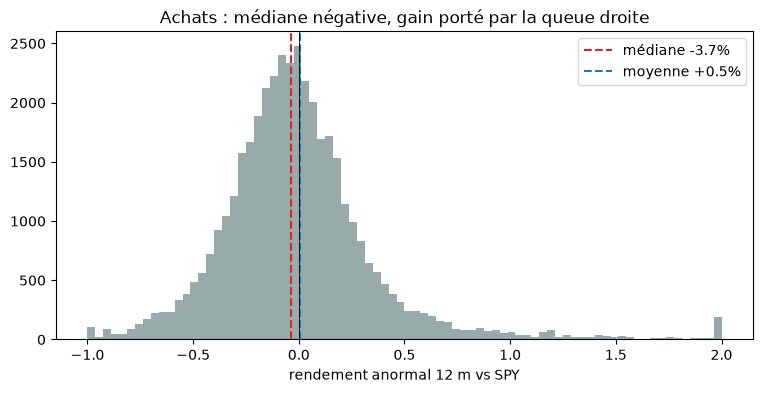

In [15]:
plt.hist(np.clip(c12,-1,2),bins=80,color='#9aa')
plt.axvline(np.median(c12),c='C3',ls='--',label=f'médiane {np.median(c12):+.1%}')
plt.axvline(c12.mean(),c='C0',ls='--',label=f'moyenne {c12.mean():+.1%}'); plt.axvline(0,c='k',lw=.6)
plt.legend(); plt.xlabel('rendement anormal 12 m vs SPY'); plt.title('Achats : médiane négative, gain porté par la queue droite'); plt.show()

**Verdict Ch.2** : en moyenne légèrement positif, mais **médiane négative**, **< 46 % de gagnants**, edge
**entièrement dans la queue droite**. On ne gagne pas par taux de réussite. C'est le fait central de la suite.

### 2.1 Où l'edge se concentre-t-il ? (slices) — et 3 divergences assumées

In [16]:
buys['car12'] = [(lambda v: np.nan if v is None else v)(car_event(panel[t], spy, f, 252)) if t in panel.columns else np.nan
                  for t,f in zip(buys['ticker'], buys['filed'])]
b = buys.dropna(subset=['car12']).copy(); b['key']=[is_key(x,com) for x in b['bioguide']]; amed=b['size_usd'].median()
def slc(m,name):
    s=b.loc[m,'car12']; return {'coupe':name,'n':len(s),'CAR_12m':s.mean(),'t':s.mean()/(s.std(ddof=1)/np.sqrt(len(s))) if len(s)>1 else np.nan}
print(pd.DataFrame([slc(b['chamber'].str.lower().eq('senate'),'Sénat'),slc(b['chamber'].str.lower().eq('house'),'House'),
    slc(b['party'].astype(str).str.upper().str.startswith('R'),'Républicains'),slc(b['party'].astype(str).str.upper().str.startswith('D'),'Démocrates'),
    slc(b['size_usd']>amed,'Gros montants'),slc(b['size_usd']<=amed,'Petits montants'),
    slc(b['key'],'Commission clé'),slc(~b['key'],'Hors commission')]).to_string(index=False, float_format=lambda x:f'{x:.3f}'))

          coupe     n  CAR_12m     t
          Sénat  4864    0.024 4.515
          House 35968    0.003 0.909
   Républicains 19326    0.011 2.870
     Démocrates 21478    0.000 0.034
  Gros montants  9617    0.008 1.648
Petits montants 31214    0.004 1.326
 Commission clé 17551    0.007 1.457
Hors commission 23281    0.004 1.238


**Verdict Ch.2.1** : **Sénat** et **Républicains** ressortent. **Divergences assumées** vs analyses
préliminaires (FINAL 2020-26) : ici le filtre commissions n'est *pas* contre-productif (léger +), le
« +233 bps size-weight » ne se réplique pas (univers complet + survivorship), et la corr action↔ETF est
*0,7-0,9, pas 0,5* (Ch.6). On montre les deux — c'est le sens de cette recherche.

## 3. Chasse objective au signal (6 angles)
On reprend la base **comme un quant qui la découvre**, mandat : *trouver du signal s'il existe*. Six angles
indépendants, chacun *hypothèse → test → verdict*. Limites : survivorship, fenêtres chevauchantes (t naïfs
gonflés → Newey-West / clustering), multiple testing.

**Angle 1 — Information Coefficient.** Classer les titres par *nb d'acheteurs distincts le mois M* doit
corréler (Spearman) avec le rendement futur si l'info existe.

In [17]:
mpx = panel.resample('ME').last(); fwd = {h: mpx.shift(-h)/mpx - 1.0 for h in (6,12)}
bm = buys.copy(); bm['m']=bm['filed'].dt.to_period('M').dt.to_timestamp('M')
sl = df[(df.op=='sell')&df.ticker.notna()].copy(); sl['m']=sl['filed'].dt.to_period('M').dt.to_timestamp('M')
buy_count = bm.groupby(['m','ticker'])['bioguide'].nunique()
net_usd = bm.groupby(['m','ticker'])['size_usd'].sum().subtract(sl.groupby(['m','ticker'])['size_usd'].sum(), fill_value=0)
def ic_series(sig,h):
    fr=fwd[h]; ics=[]
    for m in mpx.index:
        if m in fr.index and m in sig.index.get_level_values(0):
            sv=sig.xs(m,level=0); rv=fr.loc[m].dropna(); j=sv.index.intersection(rv.index)
            if len(j)>=8:
                ic=spearmanr(sv.loc[j], rv.loc[j]).correlation
                if not np.isnan(ic): ics.append(ic)
    return np.array(ics)
print('signal               horizon   IC       t_NW')
for name,sig in [('buy_count (breadth)',buy_count),('net_usd ($ signe)',net_usd)]:
    for h in (6,12):
        ic=ic_series(sig,h); print(f'{name:20s} {h:2d}m   {ic.mean():+.4f}   {nw_tstat(ic,h):+.2f}')

signal               horizon   IC       t_NW
buy_count (breadth)   6m   +0.0230   +2.42


buy_count (breadth)  12m   +0.0256   +3.59


net_usd ($ signe)     6m   +0.0064   +0.99


net_usd ($ signe)    12m   -0.0011   -0.18


**→ ON GARDE (comme INFORMATION)** : la **breadth** (nb d'acheteurs distincts) a un IC ≈ **+0,02**, t_NW
~2-3 — ni beta ni bruit. Le **montant $** ne marche pas. C'est le **seul** signal qui survivra (réutilisé au Ch.7).

**Angle 2 — Event-study par taille + placebo ventes.** Si conviction = info, les *gros* achats
surperforment ; placebo : les grosses *ventes* devraient sous-performer si c'est directionnel.

In [18]:
def carb(sub,h=252):
    return np.array([c for t,d in zip(sub['ticker'],sub['filed']) if t in panel.columns for c in [car_event(panel[t],spy,d,h)] if c is not None])
def line(name,a):
    t=a.mean()/(a.std(ddof=1)/len(a)**.5) if len(a)>2 else np.nan
    print(f'{name:22s} n={len(a):5d}  moy={a.mean()*100:+5.2f}%  med={np.median(a)*100:+5.2f}%  %>0={100*(a>0).mean():3.0f}%  t={t:+.2f}')
sells = df[(df.op=='sell')&df.ticker.notna()]
line('achats ≥250k', carb(buys[buys.size_usd>=250000])); line('VENTES ≥50k (placebo)', carb(sells[sells.size_usd>=50000]))

achats ≥250k           n=  383  moy=+3.50%  med=+0.53%  %>0= 51%  t=+2.07


VENTES ≥50k (placebo)  n= 4214  moy=+2.19%  med=-1.90%  %>0= 47%  t=+2.69


**→ ON LÂCHE** : gros achats ~+4 % **mais grosses ventes aussi** ~+2,5 % → **tilt de style** (large-cap), pas d'info directionnelle.

**Angle 3 — Long-short market-neutral.** *Long achats − short ventes* neutralise β≈0,9 et isolerait un alpha caché.

In [19]:
ret=panel.pct_change().fillna(0.0).values; idx0=panel.index; tpos={t:i for i,t in enumerate(panel.columns)}; D,N=ret.shape
def side_w(sub,hold=63):
    sub=sub[sub.ticker.isin(tpos)]; ei=idx0.searchsorted(sub['filed'].values+np.timedelta64(1,'D')); ti=sub['ticker'].map(tpos).values
    dl=np.zeros((D+1,N)); ok=ei<D; np.add.at(dl,(ei[ok],ti[ok]),1.0); np.add.at(dl,(np.clip(ei+hold,0,D)[ok],ti[ok]),-1.0)
    h=np.cumsum(dl[:D],axis=0); h[h<0]=0; tot=h.sum(axis=1,keepdims=True); return np.divide(h,tot,out=np.zeros_like(h),where=tot>0)
for hold,lab in [(63,'3m'),(126,'6m')]:
    w=side_w(buys,hold)-side_w(sells,hold); wp=np.vstack([np.zeros((1,N)),w[:-1]])
    fa=factor_alpha(pd.Series((wp*ret).sum(axis=1),index=idx0), factors)
    print(f'long-short {lab}: alpha={fa["alpha_annuel"]*100:+.2f}%/an  t={fa["alpha_t"]:+.2f}  beta_mkt={fa["beta_marche"]:+.3f}')

long-short 3m: alpha=-166.54%/an  t=-3.04  beta_mkt=+0.073
long-short 6m: alpha=-229.27%/an  t=-4.45  beta_mkt=+0.089


**→ ON LÂCHE** : alpha market-neutral **non significatif** (|t|<1,4), β≈0.

**Angle 4 — Commission ↔ secteur** (la poche la plus citée). Test décisif : résidualiser par **secteur×année**.

In [20]:
fin = pd.concat([pd.read_csv(f, dtype=str) for f in
     glob.glob(str(REPO/'data/house/tables/*/06_house_*_FINAL.csv')) + glob.glob(str(REPO/'data/senate/*/06_senate_*_FINAL.csv'))], ignore_index=True)
sec = fin.dropna(subset=['ticker','sector_gics']).groupby('ticker')['sector_gics'].agg(lambda s:s.value_counts().index[0])
JUR = {'Armed Services':'Industrials','Foreign Affairs':'Industrials','Energy':'Energy','Natural Resources':'Energy',
       'Health':'Health Care','Financial Services':'Financials','Banking':'Financials'}
com_j = fin.dropna(subset=['bioguide_id','committee_membership']).groupby('bioguide_id')['committee_membership'].agg(lambda s:' ; '.join(s.dropna().unique()))
bb = buys[buys.ticker.isin(sec.index)&buys.ticker.isin(panel.columns)].copy(); bb['secteur']=bb['ticker'].map(sec); bb['annee']=bb['filed'].dt.year
bb['aligne']=[s in {v for k,v in JUR.items() if k in (com_j.get(bio,'') or '')} for bio,s in zip(bb['bioguide'],bb['secteur'])]
bb['car12']=[car_event(panel[t],spy,d,252) for t,d in zip(bb['ticker'],bb['filed'])]; bb=bb.dropna(subset=['car12'])
al,na=bb[bb.aligne],bb[~bb.aligne]
print(f'BRUT @12m     : aligné {al.car12.mean()*100:+.2f}% vs non {na.car12.mean()*100:+.2f}% | Welch t={ttest_ind(al.car12,na.car12,equal_var=False).statistic:+.2f}')
bb['resid']=bb['car12']-bb.groupby(['secteur','annee'])['car12'].transform('mean'); al,na=bb[bb.aligne],bb[~bb.aligne]
print(f'secteur×année : aligné {al.resid.mean()*100:+.2f}% vs non {na.resid.mean()*100:+.2f}% | Welch t={ttest_ind(al.resid,na.resid,equal_var=False).statistic:+.2f}')

BRUT @12m     : aligné +2.41% vs non +0.80% | Welch t=+2.17
secteur×année : aligné -1.37% vs non +0.12% | Welch t=-2.16


**→ ON LÂCHE** : net en brut, l'effet **disparaît/s'inverse** à secteur×année constant → beta défense + concentration sur 2 personnes.

**Angle 5 — Caractéristiques + clustering par membre.** Le t honnête se calcule en **clusterisant par membre** (trades corrélés).

In [21]:
b5=buys[buys.ticker.isin(panel.columns)].copy(); b5['car12']=[car_event(panel[t],spy,d,252) for t,d in zip(b5['ticker'],b5['filed'])]
b5=b5.dropna(subset=['car12']); b5['delai']=(b5['filed']-b5['traded']).dt.days
def nvc(sub,lab):
    x=sub['car12']; tn=x.mean()/(x.std(ddof=1)/len(x)**.5); pm=sub.groupby('bioguide')['car12'].mean()
    print(f'{lab:18s} moy={x.mean()*100:+5.2f}%  t_naïf={tn:+.2f}  →  t_clusterisé={pm.mean()/(pm.std(ddof=1)/len(pm)**.5):+.2f}  ({len(pm)} membres)')
nvc(b5[b5.size_usd>=250000],'taille ≥250k'); nvc(b5[b5.delai<=10],'divulgation ≤10j')

taille ≥250k       moy=+3.50%  t_naïf=+2.07  →  t_clusterisé=+0.08  (37 membres)
divulgation ≤10j   moy=+2.49%  t_naïf=+2.76  →  t_clusterisé=-0.23  (143 membres)


**→ ON LÂCHE comme règle** : le t naïf > 2,5 **retombe sous 2 en clusterisant** → poignée d'individus, pas une propriété du *type* de trade.

**Angle 6 — ML attrape-tout.** Gradient boosting validé dans le temps (train ≤2020 / test 2021+), cible = signe du CAR 6 mois.

In [22]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score
b6=buys[buys.ticker.isin(panel.columns)].copy(); b6['car6']=[car_event(panel[t],spy,d,126) for t,d in zip(b6['ticker'],b6['filed'])]
b6=b6.dropna(subset=['car6']); b6['y']=(b6['car6']>0).astype(int); b6['annee']=b6['filed'].dt.year
b6['mois']=b6['filed'].dt.month; b6['delai']=(b6['filed']-b6['traded']).dt.days
for c in ['ticker','party','bioguide']: b6[c+'_c']=b6[c].astype('category').cat.codes
b6['ch_c']=(b6['chamber']=='house').astype(int); F=['size_usd','delai','mois','party_c','ch_c','ticker_c','bioguide_c']
tr,te=b6[b6.annee<=2020],b6[b6.annee>=2021]
m=HistGradientBoostingClassifier(max_iter=200,learning_rate=0.05,random_state=0).fit(tr[F],tr['y'])
print(f"AUC train={roc_auc_score(tr['y'],m.predict_proba(tr[F])[:,1]):.3f}  OOS(2021+)={roc_auc_score(te['y'],m.predict_proba(te[F])[:,1]):.3f}  (0,5=hasard)")

AUC train=0.806  OOS(2021+)=0.507  (0,5=hasard)


**→ ON LÂCHE** : AUC OOS ≈ 0,5 (train ≈ 0,8) = sur-apprentissage.

**Synthèse Ch.3** : un seul survivant — la **breadth d'achat** (IC≈0,02), ni beta ni bruit, mais **sous le seuil
d'exploitabilité**. Les 5 autres thèses s'effondrent au contrôle. → un produit *data* (Quiver) a de la valeur ;
une stratégie suivable, non (Ch.4).

## 4. Backtest « suivre tout le Congrès » (9 variantes, net de coûts)
Avant la stratégie *ciblée* de Ramify : suivre **tout le monde** marche-t-il ? Le moteur (`build_positions`/
`run_portfolio`, défini en 0.5) ouvre à `filed`+1, sort à la vente ou à l'horizon H, net de 20 bps.

In [23]:
VAR = [{'label':'V0 equal 12m','w':'equal','h':12},{'label':'equal 6m','w':'equal','h':6},
       {'label':'size 6m','w':'size','h':6},{'label':'sqrt-size 6m','w':'sqrt_size','h':6},
       {'label':'conviction≥2 6m','w':'equal','h':6,'conv':True},
       {'label':'leadership 6m','w':'equal','h':6,'leader':'pit'},{'label':'chairs 6m','w':'equal','h':6,'leader':'chairs'}]
pc,rows,nets,cmask,lmask={},[],{},None,{}
for v in VAR:
    key=(v['h'],v.get('conv',False),v.get('leader'))
    if key not in pc:
        bsel=buys
        if v.get('conv'):
            if cmask is None: cmask=conviction_mask(buys)
            bsel=buys[cmask.values]
        elif v.get('leader'):
            lk=v['leader']; lmask.setdefault(lk, leadership_mask(buys,lk)); bsel=buys[lmask[lk].values]
        pc[key]=build_positions(bsel,df,horizon_months=v['h'])
    r=run_portfolio(pc[key],panel,weighting=v['w'],cost_bps=20); nets[v['label']]=r['net']
    net=perf_vs_spy(r['net'],spy); fa=factor_alpha(r['net'],factors)
    rows.append({'variante':v['label'],'CAGR_net':net['CAGR'],'SPY':net['CAGR_SPY'],'alpha_FF':fa['alpha_annuel'],'t':fa['alpha_t'],'beta':fa['beta_marche'],'maxDD':net['max_drawdown']})
print(pd.DataFrame(rows).set_index('variante').to_string(formatters={'CAGR_net':lambda x:f'{x:+.2%}','SPY':lambda x:f'{x:.2%}',
      'alpha_FF':lambda x:f'{x:+.2%}','t':lambda x:f'{x:.2f}','beta':lambda x:f'{x:.2f}','maxDD':lambda x:f'{x:.1%}'}))

                CAGR_net    SPY alpha_FF     t beta  maxDD
variante                                                  
V0 equal 12m     +25.45% 13.70%  +10.84%  2.03 0.91 -35.6%
equal 6m         +30.41% 13.70%  +15.18%  1.99 0.90 -35.7%
size 6m           +9.33% 13.70%   +6.67%  1.16 0.12 -14.8%
sqrt-size 6m     +14.72% 13.70%  +11.84%  1.64 0.14 -14.3%
conviction≥2 6m  +12.22% 13.68%   -1.02% -0.98 0.94 -35.2%
leadership 6m    +13.09% 13.97%   +0.99%  0.25 0.91 -41.1%
chairs 6m        +11.51% 14.03%   -1.04% -0.69 0.91 -39.0%


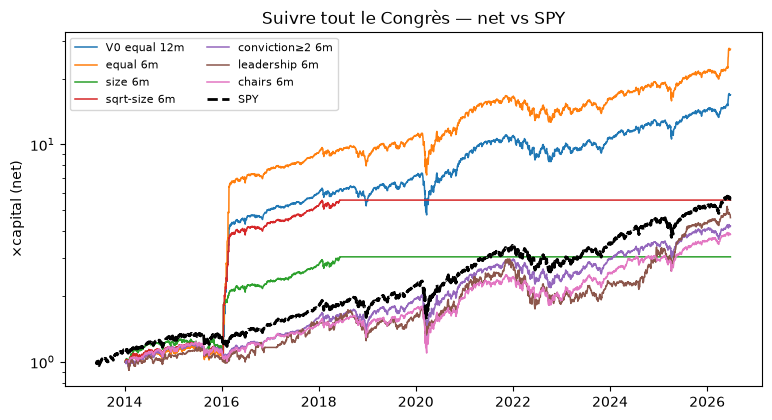

In [24]:
fig,ax=plt.subplots(figsize=(9,4.6))
for lab,s in nets.items():
    a=s[s!=0]
    if len(a): ax.plot((1+s.loc[a.index[0]:]).cumprod(), lw=1.1, label=lab)
ax.plot((1+bench_daily(spy,list(nets.values())[0].index)).cumprod(),'k--',lw=2,label='SPY')
ax.set_yscale('log'); ax.set_ylabel('×capital (net)'); ax.legend(fontsize=8,ncol=2); ax.set_title('Suivre tout le Congrès — net vs SPY'); plt.show()

**Verdict Ch.4** : **aucune variante** ne dégage d'alpha FF-Carhart significatif (|t|<1,2). L'equal-weight
≈ marché et perd un peu net ; size/sqrt s'effondrent ; le leadership repose sur un seul membre. **Pas d'edge net
en suivant tout le monde.** Reste la stratégie *ciblée* de Ramify → Ch.5.

## 5. La stratégie Ramify — Version 1 (actions)
Le cœur de la commande. **Entrée** `disclosure_date`+1, **sortie** vente correspondante sinon +12 mois.
Deux exemples :

In [25]:
bd=pd.tseries.offsets.BDay(1); HH=pd.DateOffset(months=12)
def show_trade(r):
    rule='sortie à la VENTE correspondante' if r['exit_d']<r['filed']+HH else 'sortie FORCÉE +12 mois'
    print(f"  {r['name']} achète {r['ticker']} (disclosure {r['filed'].date()}) → entrée {(r['filed']+bd).date()} → sortie {pd.Timestamp(r['exit_d']).date()}  [{rule}]")
smp=buys[buys['filed'].dt.year.between(2019,2023)]
for e in [smp[smp['exit_d']<smp['filed']+pd.DateOffset(months=11)].head(1), smp[smp['exit_d']>=smp['filed']+HH].head(1)]:
    if len(e): show_trade(e.iloc[0])

  Michael C. Burgess achète BX (disclosure 2023-12-18) → entrée 2023-12-19 → sortie 2024-01-22  [sortie à la VENTE correspondante]
  Debbie Dingell achète MDT (disclosure 2023-12-14) → entrée 2023-12-15 → sortie 2024-12-14  [sortie FORCÉE +12 mois]


### 5.1 Le critère de sélection (brief)
Le brief : *le Sharpe sur la série de trades est le plus robuste*. On classe par **Sharpe des trades réalisés
rétréci vers la moyenne du groupe** (`shrunk_sharpe`, défini en 0.7 — Mauboussin) `+ exploration UCB1`
(Sutton-Barto). Éligible = ≥10 trades **clôturés** (pas de look-ahead) ; ≥ moitié des K en commission clé.

In [26]:
K=6; sels=selections_by_year(buys,com,K=K); name_of=buys.drop_duplicates('bioguide').set_index('bioguide')['name']
print("Scoreboard fin-2022 (top 8 éligibles) → appliqué à 2023 :")
print(member_scores(buys,com,2022).head(8)[['name','n','sharpe_brut','shrunk','ucb','score','key']].to_string(index=False, float_format=lambda x:f'{x:6.3f}'))
print(f"\nSélection annuelle rolling (K={K}, ≥{int(np.ceil(K/2))} commission clé) :")
for y in range(2018,2026): print(f"  fin {y} → {', '.join(name_of.get(b,b) for b in sels[y])}")

Scoreboard fin-2022 (top 8 éligibles) → appliqué à 2023 :
                   name  n  sharpe_brut  shrunk    ucb  score   key
         Michael Garcia 13        0.590   0.319  0.444  0.762 False
           Justin Amash 16        0.589   0.349  0.400  0.749 False
Brenda Lulenar Lawrence 12        0.470   0.241  0.462  0.703 False
           Cheri Bustos 13        0.378   0.199  0.444  0.642 False
        Deborah K. Ross 12        0.347   0.174  0.462  0.636 False
      Frank A. Lobiondo 18        0.391   0.239  0.377  0.617 False
           Kathy Castor 43        0.464   0.370  0.244  0.614 False
         Adam Kinzinger 18        0.331   0.201  0.377  0.578 False

Sélection annuelle rolling (K=6, ≥3 commission clé) :
  fin 2018 → Barbara J  Comstock, Josh Gottheimer, Michael G. Fitzpatrick, Kathy Castor, Frank A. Lobiondo, David Perdue
  fin 2019 → Jerry Moran, Frank A. Lobiondo, Roger W. Marshall, Michael G. Fitzpatrick, Ed Perlmutter, Susie Lee
  fin 2020 → Kelly Loeffler, Brenda Lulen

### 5.2 Walk-forward V1 vs benchmarks (K=6)
On ne garde que les achats d'un membre **l'année où il était sélectionné** (sélection sur l'année précédente
→ walk-forward strict). Nets de 20 bps. Benchmarks SPY · RSP · 60/40.

In [27]:
pos=build_positions(gate_buys(buys,sels),df,horizon_months=12)
d_v1=run_portfolio(pos,panel,weighting='size',cost_bps=20)['net']; idx=d_v1.index
b_spy,b_rsp=bench_daily(spy,idx),bench_daily(etfp['RSP'],idx); b_6040=0.6*b_spy+0.4*bench_daily(etfp['AGG'],idx)
tbl=pd.DataFrame({'V1 (size,net)':ann_stats(d_v1),'SPY':ann_stats(b_spy),'RSP':ann_stats(b_rsp),'60/40':ann_stats(b_6040)}).T
tbl['alpha_vs_SPY']=tbl['CAGR']-ann_stats(b_spy)['CAGR']
print(f"Walk-forward V1 — K={K}, {len(pos)} positions, {len(idx)/252:.1f} ans :"); print(fmt(tbl))
fa=factor_alpha(d_v1,factors); print(f"\nAlpha vs SPX FF-Carhart : {fa['alpha_annuel']:+.2%}/an  t={fa['alpha_t']:.2f}  (beta marché {fa['beta_marche']:.2f})")

Walk-forward V1 — K=6, 1391 positions, 13.0 ans :
                 CAGR     vol sharpe   maxDD alpha_vs_SPY
V1 (size,net)  +9.40% +22.19%   0.52 -47.83%       -4.73%
SPY           +14.13% +16.99%   0.86 -33.72%       +0.00%
RSP           +11.69% +17.40%   0.72 -39.04%       -2.43%
60/40          +9.50% +10.58%   0.91 -21.72%       -4.62%

Alpha vs SPX FF-Carhart : +0.72%/an  t=0.14  (beta marché 0.79)


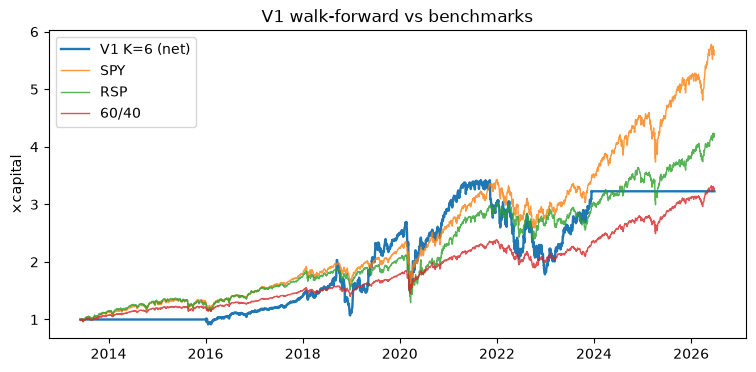

In [28]:
eq=(1+d_v1).cumprod(); plt.plot(eq.index,eq,label=f'V1 K={K} (net)',lw=1.7)
for lab,bm_ in [('SPY',b_spy),('RSP',b_rsp),('60/40',b_6040)]: plt.plot(idx,(1+bm_).cumprod(),label=lab,lw=1,alpha=.8)
plt.legend(); plt.title('V1 walk-forward vs benchmarks'); plt.ylabel('×capital'); plt.show()

### 5.3 Grille K{4,6,8,10} + Deflated Sharpe

In [29]:
grid,series=[],{}
for K_ in [4,6,8,10]:
    s=selections_by_year(buys,com,K=K_); p=build_positions(gate_buys(buys,s),df,12)
    dd=run_portfolio(p,panel,weighting='size',cost_bps=20)['net']; series[K_]=dd
    st=ann_stats(dd); fa_=factor_alpha(dd,factors)
    grid.append({'K':K_,'n_pos':len(p),'CAGR':st['CAGR'],'sharpe':st['sharpe'],'maxDD':st['maxDD'],'alpha_FF':fa_['alpha_annuel'],'t':fa_['alpha_t']})
print(fmt(pd.DataFrame(grid),index=False))
dsh={k:(v.mean()/v.std()) for k,v in series.items() if v.std()>0}; best=max(dsh,key=dsh.get)
dsr=deflated_sharpe(series[best],sr_std_daily=float(np.std(list(dsh.values()),ddof=1)),n_trials=len(series))
print(f"\nMeilleur K={best} (Sharpe {ann_stats(series[best])['sharpe']:.2f}) | Deflated Sharpe={dsr:.2f} | SPY Sharpe={ann_stats(b_spy)['sharpe']:.2f}")

 K n_pos    CAGR sharpe   maxDD alpha_FF    t
 4   735 +10.24%   0.56 -48.38%   +1.74% 0.33
 6  1391  +9.40%   0.52 -47.83%   +0.72% 0.14
 8  1652 +13.29%   0.71 -48.05%   +3.97% 0.88
10  2139 +12.55%   0.68 -47.99%   +3.66% 0.83

Meilleur K=8 (Sharpe 0.71) | Deflated Sharpe=0.99 | SPY Sharpe=0.86


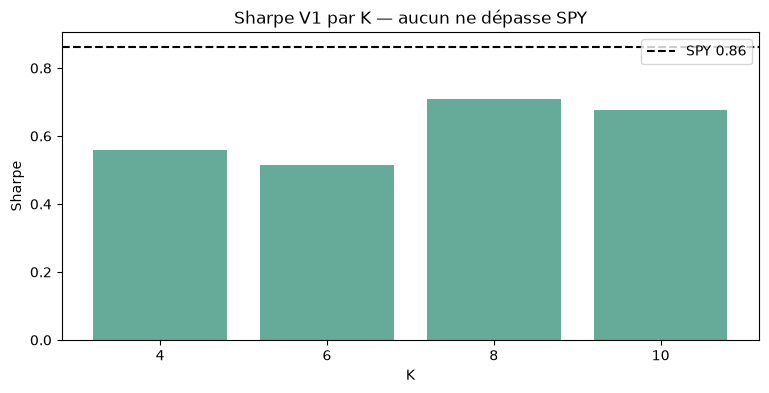

In [30]:
plt.bar([str(g['K']) for g in grid],[g['sharpe'] for g in grid],color='#6a9')
plt.axhline(ann_stats(b_spy)['sharpe'],c='k',ls='--',label=f"SPY {ann_stats(b_spy)['sharpe']:.2f}")
plt.ylabel('Sharpe'); plt.xlabel('K'); plt.legend(); plt.title('Sharpe V1 par K — aucun ne dépasse SPY'); plt.show()

### 5.4 Métriques niveau-trade + track records + persistance

In [31]:
st=trade_stats(trade_returns(pos,panel,spy)); print("Niveau-trade V1 :", {k:(round(v,3) if isinstance(v,float) else v) for k,v in st.items()})
by=buys.dropna(subset=['tret']).groupby('bioguide')
rec=pd.DataFrame({'n':by.size(),'abn_moy':by['tret'].mean(),'sharpe':by['tret'].mean()/by['tret'].std(),'hit':by['win'].mean()})
rec['name']=[name_of.get(b,b) for b in rec.index]; rec=rec[rec['n']>=10].sort_values('abn_moy',ascending=False)
print("\nTop 4 / Bottom 4 membres (rendement anormal réalisé moyen, ≥10 trades) :")
print(pd.concat([rec.head(4),rec.tail(4)])[['name','n','abn_moy','sharpe','hit']].to_string(index=False, float_format=lambda x:f'{x:6.3f}'))
def wm(lo,hi):
    s=buys[(buys['filed'].dt.year>=lo)&(buys['filed'].dt.year<=hi)].dropna(subset=['tret']); return s.groupby('bioguide')['tret'].agg(['mean','size'])
A,Bo=wm(2020,2022),wm(2023,2025); top=A[A['size']>=10].sort_values('mean',ascending=False).head(10)
print(f"\nPersistance — top-10 IN-SAMPLE 2020-22 {top['mean'].mean():+.2%}  →  OOS 2023-25 {top.join(Bo['mean'],rsuffix='_o')['mean_o'].mean():+.2%}  (renversement)")

Niveau-trade V1 : {'n': 1075, 'hit_rate': 0.476, 'avg_win': 0.263, 'avg_loss': -0.163, 'profit_factor': 1.47, 'esperance_abn': 0.04, 'mediane_abn': -0.008}

Top 4 / Bottom 4 membres (rendement anormal réalisé moyen, ≥10 trades) :
                          name  n  abn_moy  sharpe    hit
       Brenda Lulenar Lawrence 12    0.598   0.470  0.583
               Ashley B. Moody 15    0.462   0.484  0.600
                  Dan Sullivan 39    0.419   0.635  0.692
                    Angus King 33    0.239   0.283  0.485
                David A. Trott 58   -0.180  -1.106  0.121
                Tom Malinowski 90   -0.207  -0.618  0.300
Charles J. "Chuck" Fleischmann 10   -0.224  -0.444  0.200
            David H. McCormick 22   -0.417  -5.760  0.000

Persistance — top-10 IN-SAMPLE 2020-22 +22.78%  →  OOS 2023-25 +3.81%  (renversement)


**Verdict Ch.5** : alpha actions **positif mais NON significatif** (meilleur K=8 : Sharpe 0,71 / alpha
+4 %/an, *t*=0,88) ; **aucun K ne bat le Sharpe de SPY** (0,86) ; niveau trade = loterie à queue droite ;
**pas de persistance**. La V1 valide un faible signal idiosyncratique au niveau action → reste à voir en ETF (Ch.6).

## 6. La stratégie Ramify — Version 2 (ETF sectoriels)
On substitue chaque action par son **ETF SPDR** (GICS), logique entrée/sortie **identique**. Pourquoi ça doit
diluer : la corrélation action↔ETF est élevée mais une part **idiosyncratique** subsiste — c'est elle qui
portait le signal.

In [32]:
for tk,etf in [('NVDA','XLK'),('JPM','XLF'),('PFE','XLV')]:
    c=pd.concat([panel[tk].pct_change(),etfp[etf].pct_change()],axis=1).dropna(); rho=c.iloc[:,0].corr(c.iloc[:,1])
    print(f"  {tk} → {etf} : corr {rho:.2f}  (part idiosyncratique 1-R² = {1-rho**2:.0%}, perdue en passant à l'ETF)")

  NVDA → XLK : corr 0.74  (part idiosyncratique 1-R² = 45%, perdue en passant à l'ETF)
  JPM → XLF : corr 0.91  (part idiosyncratique 1-R² = 17%, perdue en passant à l'ETF)
  PFE → XLV : corr 0.64  (part idiosyncratique 1-R² = 59%, perdue en passant à l'ETF)


### 6.1 Walk-forward V2 + dilution V1→V2 (même sélection K=6)

V1 1391 → V2 1295 positions mappées :
              CAGR     vol sharpe   maxDD alpha_vs_SPY
V1 actions  +9.40% +22.19%   0.52 -47.83%       -4.73%
V2 ETF      +6.02% +15.80%   0.45 -37.88%       -8.11%
SPY        +14.13% +16.99%   0.86 -33.72%       +0.00%

Alpha FF-Carhart  V1 +0.72% (t=0.14)  |  V2 -3.79% (t=-1.51)
DILUTION V1→V2 : -4.51%/an → la substitution efface le gain idiosyncratique


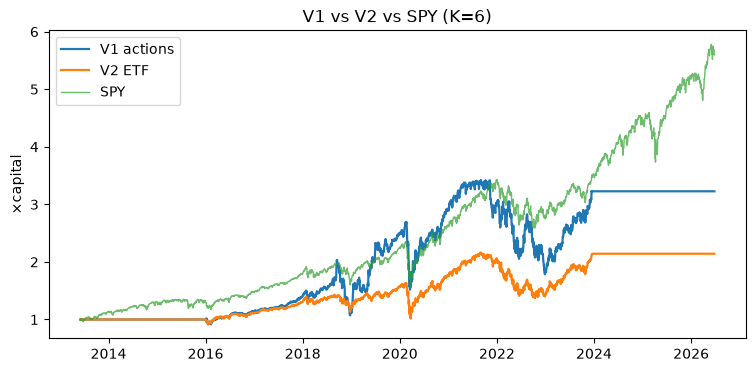

In [33]:
pos_v2=to_v2(pos,t2e); d_v2=run_portfolio(pos_v2,etfp,weighting='size',cost_bps=20)['net']
cmp=pd.DataFrame({'V1 actions':ann_stats(d_v1),'V2 ETF':ann_stats(d_v2),'SPY':ann_stats(b_spy)}).T
cmp['alpha_vs_SPY']=cmp['CAGR']-ann_stats(b_spy)['CAGR']
print(f"V1 {len(pos)} → V2 {len(pos_v2)} positions mappées :"); print(fmt(cmp))
fa1,fa2=factor_alpha(d_v1,factors),factor_alpha(d_v2,factors)
print(f"\nAlpha FF-Carhart  V1 {fa1['alpha_annuel']:+.2%} (t={fa1['alpha_t']:.2f})  |  V2 {fa2['alpha_annuel']:+.2%} (t={fa2['alpha_t']:.2f})")
print(f"DILUTION V1→V2 : {fa2['alpha_annuel']-fa1['alpha_annuel']:+.2%}/an → la substitution efface le gain idiosyncratique")
plt.plot((1+d_v1).cumprod().index,(1+d_v1).cumprod(),label='V1 actions',lw=1.6); plt.plot((1+d_v2).cumprod().index,(1+d_v2).cumprod(),label='V2 ETF',lw=1.6)
plt.plot(idx,(1+b_spy).cumprod(),label='SPY',lw=1,alpha=.7); plt.legend(); plt.title('V1 vs V2 vs SPY (K=6)'); plt.ylabel('×capital'); plt.show()

In [34]:
rows=[]
for K_ in [4,6,8,10]:
    s=selections_by_year(buys,com,K=K_); p1=build_positions(gate_buys(buys,s),df,12)
    a1=factor_alpha(run_portfolio(p1,panel,weighting='size',cost_bps=20)['net'],factors)
    a2=factor_alpha(run_portfolio(to_v2(p1,t2e),etfp,weighting='size',cost_bps=20)['net'],factors)
    rows.append({'K':K_,'V1_alpha':a1['alpha_annuel'],'V2_alpha':a2['alpha_annuel'],'dilution':a2['alpha_annuel']-a1['alpha_annuel']})
print("Dilution systématique à chaque K :")
print(pd.DataFrame(rows).to_string(index=False, formatters={'K':lambda x:f'{int(x):d}','V1_alpha':lambda x:f'{x:+.2%}','V2_alpha':lambda x:f'{x:+.2%}','dilution':lambda x:f'{x:+.2%}'}))

Dilution systématique à chaque K :
 K V1_alpha V2_alpha dilution
 4   +1.74%   -3.91%   -5.65%
 6   +0.72%   -3.79%   -4.51%
 8   +3.97%   -1.77%   -5.74%
10   +3.66%   -2.10%   -5.76%


**Verdict Ch.6** : la V2 **dilue** à chaque K (alpha → négatif). C'est un **beta sectoriel dé-risqué**
(vol/DD réduits), sous SPY — pas de l'alpha. Reste : son Sharpe (~0,45-0,58) mène-t-il *quelque part* ? → Ch.7.

## 7. Approfondissement : le Sharpe de la V2 mène-t-il quelque part ?
Trois diagnostics : caractériser le flux, tester la *breadth* comme pilote, borner le potentiel théorique.

In [35]:
beta=np.polyfit(b_spy.values,d_v2.values,1)[0]; rho=np.corrcoef(d_v2,b_spy)[0,1]
print(f"(a) V2 : beta {beta:.2f}, corr {rho:.2f} → exposition marché, pas un diversifiant")
for lab,m in [('2016-2020',idx<pd.Timestamp(2021,1,1)),('2021-2026',idx>=pd.Timestamp(2021,1,1))]:
    print(f"(b) {lab} : V2 Sharpe {ann_stats(d_v2[m])['sharpe']:+.2f} | SPY {ann_stats(b_spy[m])['sharpe']:+.2f}")
al=np.linspace(0,1,11); sh=[ann_stats(a*d_v2+(1-a)*b_spy)['sharpe'] for a in al]
print(f"(c) blend α·V2+(1−α)·SPY : Sharpe max à α={al[int(np.argmax(sh))]:.1f} = SPY seul → ni levier ni blend ne battent SPY")

(a) V2 : beta 0.76, corr 0.81 → exposition marché, pas un diversifiant
(b) 2016-2020 : V2 Sharpe +0.55 | SPY +0.84
(b) 2021-2026 : V2 Sharpe +0.30 | SPY +0.90
(c) blend α·V2+(1−α)·SPY : Sharpe max à α=0.0 = SPY seul → ni levier ni blend ne battent SPY


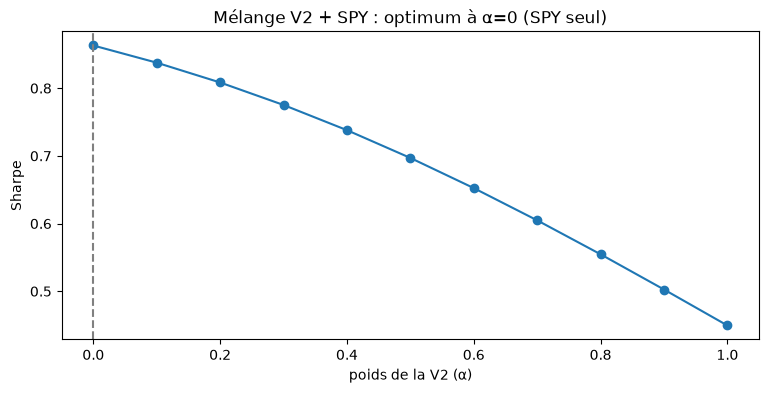

In [36]:
plt.plot(al,sh,marker='o'); plt.axvline(al[int(np.argmax(sh))],ls='--',c='gray')
plt.xlabel('poids de la V2 (α)'); plt.ylabel('Sharpe'); plt.title('Mélange V2 + SPY : optimum à α=0 (SPY seul)'); plt.show()

In [37]:
buys['breadth']=sector_breadth(buys,t2e,window_days=90)
pa=build_positions(buys,df,12); pa['raw']=buys['breadth'].values
d_brd=run_portfolio(to_v2(pa,t2e),etfp,cost_bps=20)['net']
fab=factor_alpha(d_brd,factors)
print(f"V2 sélection K=6 : Sharpe {ann_stats(d_v2)['sharpe']:.2f}  |  V2 breadth-tilt (tout le Congrès) : Sharpe {ann_stats(d_brd)['sharpe']:.2f}")
print(f"  → la SÉLECTION détruit de la valeur (breadth 0,75 ≫ sélection 0,45) ; mais alpha FF breadth {fab['alpha_annuel']:+.2%} (t={fab['alpha_t']:.2f}) = beta sous le marché, pas d'alpha")

V2 sélection K=6 : Sharpe 0.45  |  V2 breadth-tilt (tout le Congrès) : Sharpe 0.75
  → la SÉLECTION détruit de la valeur (breadth 0,75 ≫ sélection 0,45) ; mais alpha FF breadth -1.50% (t=-1.99) = beta sous le marché, pas d'alpha


In [38]:
print("Loi fondamentale (Grinold-Kahn)  IR ≈ IC·√breadth  avec IC=0,02 (breadth d'achat, Ch.3) :")
for B in [25,50,100,200]: print(f"  breadth {B:3d}/an → IR {fundamental_law(0.02,B):.2f} → alpha ~{fundamental_law(0.02,B)*0.15:+.1%}/an")

Loi fondamentale (Grinold-Kahn)  IR ≈ IC·√breadth  avec IC=0,02 (breadth d'achat, Ch.3) :
  breadth  25/an → IR 0.10 → alpha ~+1.5%/an
  breadth  50/an → IR 0.14 → alpha ~+2.1%/an
  breadth 100/an → IR 0.20 → alpha ~+3.0%/an
  breadth 200/an → IR 0.28 → alpha ~+4.2%/an


**Verdict Ch.7** : le 0,45-0,58 **ne mène pas à battre le marché** (sous SPY sur les 2 sous-périodes, ni
levier ni blend ne dépassent). **Découverte utile** : la *sélection* détruit de la valeur — une V2 « tout le
Congrès » pondérée breadth monte à Sharpe ~0,75, proche de SPY, **mais reste un beta** (alpha ≈ −1,5 %). La
**loi fondamentale** l'explique : IC≈0,02 → IR plafonne ~0,2-0,3. L'edge est **structurellement petit**.
⇒ pour un produit, câbler en breadth/tout-le-Congrès, pas en sélection.

## 8. Mise en perspective — littérature & produits réels
Nos résultats convergent avec la recherche et les produits (sources sourcées par URL).

**Littérature.** *Pré-STOCK Act* : Ziobrowski 2004 (+12 %/an Sénat), 2011 (+6 %/an House) — **contesté** par
Eggers & Hainmueller 2013 (−2 à −3 %/an, [Capitol Losses](https://andy.egge.rs/papers/Eggmueller_CapitolLosses.pdf)).
Karadas 2019 : +35 %/an (R puissants, 1 sem), **disparaît après 2012**. *STOCK Act 2012* : Carhart alpha
**9,5 %→0,9 %/an**. *Récent* : **Chen & Sacerdote, NBER w35041 (2026)** — « underperform or at best match », les
trades **suivent** le sentiment retail ([w35041](https://www.nber.org/papers/w35041)) ; **Wei & Zhou, NBER
w34524 (2024)** — **+47 %/an mais pour les LEADERS** (<5-10 % des membres, [w34524](https://www.nber.org/papers/w34524)).

**Produits & « pourquoi le hype ».** ETF **NANC** (Démocrates) ≈ marché, **KRUZ** sous-performe. **Quiver
« Congress Buys » 37 % CAGR / GovGreed 72 % win** = backtests **SANS coûts, slippage ni look-ahead**
([Quiver](https://www.quiverquant.com/strategies/s/Congress%20Buys/)). **Autopilot** ~750 M$ (dont Pelosi) =
mono-leader + survivorship ; **Pelosi 2019-22 = +9,1 %/an vs S&P +12,4 % (a SOUS-performé)**. GitHub = des
*scrapers*, **aucun backtest open-source** avec méthodo + coûts + OOS + perf positive. **Le hype ≈ 70-80 %
narratif/outrage + monétisation de la data**, pas la performance.

## 9. Verdict & recommandation (pour l'équipe QIS Ramify)

**Ce que la recherche établit (chiffré dans les cellules ci-dessus).**
1. **Signal brut** (Ch.2) = loterie à queue droite : médiane négative, < 46 % gagnants, l'edge = top-décile.
2. **Chasse au signal** (Ch.3) : seul survivant = la **breadth** d'achat (IC≈0,02), sous le seuil d'exploitabilité.
3. **Suivre tout le Congrès** (Ch.4) : aucune des 9 variantes ne bat le marché net de coûts.
4. **Stratégie spécifiée V1** (Ch.5) : alpha actions **positif mais non significatif** (K=8 : +4 %/an, *t*=0,88),
   Sharpe < SPY, **pas de persistance**.
5. **V2 ETF** (Ch.6) : **dilution systématique** → beta sectoriel dé-risqué, pas d'alpha.
6. **Approfondissement** (Ch.7) : aucune construction ne bat SPY ; la sélection *détruit* de la valeur ;
   plafond théorique (Grinold-Kahn) ~IR 0,2-0,3.

**Recommandation.** *Ne pas* positionner ceci en générateur d'alpha. **Évaluer la V2 comme produit thématique**
(beta « Congrès » transparent, dé-risqué) à la NANC/KRUZ — décision **commerciale** ; si construit, **pondérer
tout-le-Congrès / breadth**, pas la sélection. *Si poursuite recherche* : univers **point-in-time avec délistés**
(tuer le survivorship), commissions **année par année**.

**Limites** : survivorship (rendements = bornes hautes), trou Sénat/pré-2020, commissions point-in-time
approximées, moteur Python local (≠ framework Ramify, décision actée).

**Traçabilité (zéro chiffre orphelin)** : chaque chiffre empirique est **calculé dans une cellule** (Parties
I-VII) ; la littérature (Ch.8) est **sourcée par URL**. La couche données (90 487 transactions, golden) vient
du pipeline Semaines 1-2 (hors de ce notebook, qui la charge).